# Lookman-Style GP Active Learning (Figure-Style Reproduction)

This notebook reproduces the model idea shown in the paper figure:
- fit a Gaussian Process (GP) to initial data
- compute prediction mean and uncertainty
- choose next point at largest uncertainty
- update the model and re-plot

Ground-truth function used here is the polynomial shown in the figure caption of the paper.

In [1]:
%pip -q install numpy matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

In [3]:
# Ground truth from the paper's figure caption
# Response = -826.815 x^6 + 2443.982 x^5 - 2573.867 x^4 + 1093.097 x^3 - 118.369 x^2 - 14.842 x + 5.087
def f_true(x):
    x = np.asarray(x)
    return (-826.815 * x**6
            + 2443.982 * x**5
            - 2573.867 * x**4
            + 1093.097 * x**3
            - 118.369 * x**2
            - 14.842 * x
            + 5.087)

X_grid = np.linspace(0.0, 1.0, 600).reshape(-1, 1)
y_grid = f_true(X_grid).ravel()

rng = np.random.default_rng(7)
n_init = 5

In [4]:
def make_gp():
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.15, length_scale_bounds=(1e-3, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
    return GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=0,
    )

def fit_predict(X_train):
    y_train = f_true(X_train).ravel()
    gp = make_gp()
    gp.fit(X_train, y_train)
    mu, std = gp.predict(X_grid, return_std=True)
    return gp, y_train, mu, std

def choose_next_by_uncertainty(X_train, std):
    train_idx = set(np.searchsorted(X_grid.ravel(), np.round(X_train.ravel(), 12)).tolist())

    # robust alternative: mask by closeness instead of exact index
    mask = np.ones(len(X_grid), dtype=bool)
    for xt in X_train.ravel():
        mask &= np.abs(X_grid.ravel() - xt) > 1e-12

    candidate_idx = np.argmax(np.where(mask, std, -np.inf))
    return int(candidate_idx), X_grid[candidate_idx:candidate_idx+1]


In [5]:
# Initial training set
init_idx = np.sort(rng.choice(len(X_grid), size=n_init, replace=False))
X_train0 = X_grid[init_idx]

gp0, y_train0, mu0, std0 = fit_predict(X_train0)
next_idx, X_new = choose_next_by_uncertainty(X_train0, std0)
y_new = f_true(X_new).ravel()

# Updated set after one AL iteration
X_train1 = np.vstack([X_train0, X_new])
X_train1 = X_train1[np.argsort(X_train1.ravel())]
gp1, y_train1, mu1, std1 = fit_predict(X_train1)

print('Initial training x:', np.round(X_train0.ravel(), 4))
print('Suggested next x (largest uncertainty):', float(X_new.ravel()[0]))
print('Predicted mu/std at next x BEFORE observing:', float(mu0[next_idx]), float(std0[next_idx]))
print('Observed y at next x:', float(y_new[0]))

Initial training x: [0.5776 0.6227 0.6828 0.8965 0.9399]
Suggested next x (largest uncertainty): 0.0
Predicted mu/std at next x BEFORE observing: 7.638452174193583 0.682329006640626
Observed y at next x: 5.087


/Users/42d/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/42d/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/42d/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/42d/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/42d/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean 

/var/folders/99/pbwmmd_11vq4grmtfv52lnxm0000gp/T/ipykernel_26606/3692118605.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[0].annotate('Largest uncertainty', xy=(float(X_new), float(mu0[next_idx])), xytext=(0.72, float(mu0[next_idx]) - 1.0), arrowprops=dict(arrowstyle='->', lw=1.2))


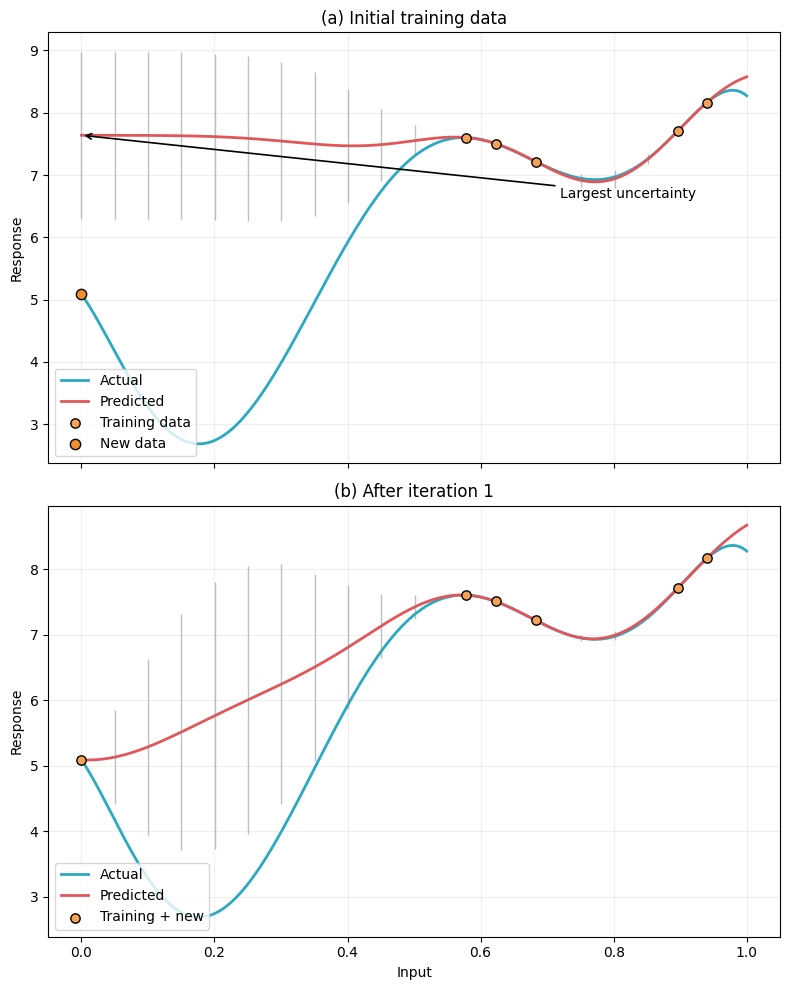

In [6]:
# Figure similar to paper panel (a) and (b)
fig, ax = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# (a) Initial model
ax[0].plot(X_grid, y_grid, color='#2ca9c2', lw=2, label='Actual')
ax[0].plot(X_grid, mu0, color='#e15759', lw=2, label='Predicted')
ax[0].errorbar(X_grid.ravel()[::30], mu0[::30], yerr=1.96 * std0[::30], fmt='none', ecolor='gray', alpha=0.5, elinewidth=1)
ax[0].scatter(X_train0, y_train0, s=45, color='#f4a259', edgecolor='k', label='Training data', zorder=3)
ax[0].scatter(X_new, y_new, s=55, color='#f28e2b', edgecolor='k', label='New data', zorder=4)
ax[0].annotate('Largest uncertainty', xy=(float(X_new), float(mu0[next_idx])), xytext=(0.72, float(mu0[next_idx]) - 1.0), arrowprops=dict(arrowstyle='->', lw=1.2))
ax[0].set_title('(a) Initial training data')
ax[0].set_ylabel('Response')
ax[0].legend(loc='lower left')

# (b) After one iteration
ax[1].plot(X_grid, y_grid, color='#2ca9c2', lw=2, label='Actual')
ax[1].plot(X_grid, mu1, color='#e15759', lw=2, label='Predicted')
ax[1].errorbar(X_grid.ravel()[::30], mu1[::30], yerr=1.96 * std1[::30], fmt='none', ecolor='gray', alpha=0.5, elinewidth=1)
ax[1].scatter(X_train1, y_train1, s=45, color='#f4a259', edgecolor='k', label='Training + new', zorder=3)
ax[1].set_title('(b) After iteration 1')
ax[1].set_xlabel('Input')
ax[1].set_ylabel('Response')
ax[1].legend(loc='lower left')

for a in ax:
    a.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [7]:
# Prediction function results at selected probe points
probe_x = np.array([0.05, 0.20, 0.35, 0.50, 0.65, 0.80, 0.95]).reshape(-1, 1)
mu_probe0, std_probe0 = gp0.predict(probe_x, return_std=True)
mu_probe1, std_probe1 = gp1.predict(probe_x, return_std=True)
y_probe = f_true(probe_x).ravel()

print('x    y_true   mu_init  std_init  mu_after1 std_after1')
for x, yt, m0, s0, m1, s1 in zip(probe_x.ravel(), y_probe, mu_probe0, std_probe0, mu_probe1, std_probe1):
    print(f'{x:0.2f}  {yt:7.3f}  {m0:7.3f}   {s0:7.3f}   {m1:7.3f}   {s1:7.3f}')

x    y_true   mu_init  std_init  mu_after1 std_after1
0.05    4.170    7.638     0.682     5.128     0.364
0.20    2.740    7.616     0.681     5.759     1.041
0.35    4.951    7.498     0.588     6.500     0.731
0.50    7.300    7.551     0.128     7.416     0.093
0.65    7.385    7.390     0.005     7.386     0.002
0.80    6.966    6.936     0.073     6.984     0.036
0.95    8.244    8.255     0.010     8.262     0.006


## Notes
- This mirrors the paper's uncertainty-driven update logic.
- For targeted design, replace the acquisition with `score = std - alpha * |mu - target_y|`.
- You can extend this loop to multiple iterations and higher-dimensional candidate spaces.